In [20]:
import xarray as xr

xr.open_zarr('/scratch4/workspace/tlanghorst_umass_edu-zbs_vD/ABOM-113129010')

<xarray.Dataset> Size: 89MB
Dimensions:    (date: 16802, subbasin: 33)
Coordinates:
  * date       (date) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-12-31
  * subbasin   (subbasin) <U14 2kB '56122884' '56127812' ... 'ABOM-113129010'
Data variables: (12/20)
    d2m_mean   (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    d2m_var    (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    e_mean     (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    e_var      (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    fal_mean   (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    fal_var    (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    ...         ...
    strd_mean  (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    strd_var   (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    t2m_mean   (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    t2m_var    (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    tp_mean    (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>
    tp_var     (date, subbasin) float64 4MB dask.array<chunksize=(365, 33), meta=np.ndarray>

In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

import sys
import pickle
from pathlib import Path

import pandas as pd
import geopandas as gpd 
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt

import config, data, models, train, evaluate

In [8]:
era5_run_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_gmm_clip/era5_20260204_210137")
era5_trainer = train.Trainer.load_last_checkpoint(era5_run_dir)

swot_run_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_gmm_clip/swot_minimal_20260204_210513")
swot_trainer = train.Trainer.load_last_checkpoint(swot_run_dir)

Loading model from /nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_gmm_clip/era5_20260204_210137/checkpoints/step_024681
Model contains 686,348 parameters
Loading trainer from checkpoint step_024681
Logging at /nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_gmm_clip/era5_20260204_210137
Loading model from /nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_gmm_clip/swot_minimal_20260204_210513/checkpoints/step_014607
Model contains 730,956 parameters
Loading trainer from checkpoint step_014607
Logging at /nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_gmm_clip/swot_minimal_20260204_210513


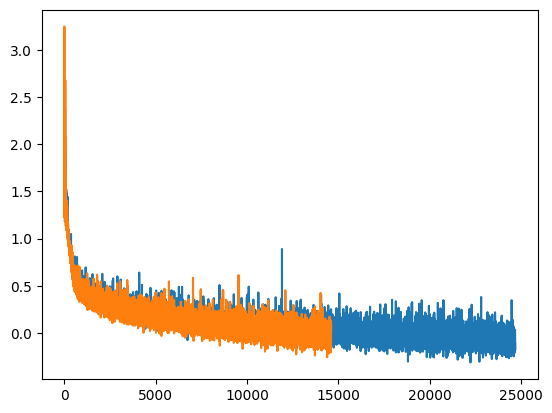

In [10]:
plt.plot(era5_trainer.losses)
plt.plot(swot_trainer.losses)